In [2]:
print("Started................")

Started................


In this Notebook, 

I am trying to use BDR (Bi-Dimensional Regression) on our Sketchmaps.
Rather than being a statistic, BDR is more like a framework, where multiple statistical measures are used. #

These statistical measures are as follows:

1. r -> Correlation coefficient (This shows how the map overall looks like)
2. R^2 -> Covariance (How well is everything placed in the sketchmap)
3. DI -> Distortion Index (from 0 to 100, shows how messy a drawing is, or how distorted is a sketchmap.)
4. Alpha 1 -> Horizontal shift (did the person shift all the building in the east?) Negative value indicates West
5. Alpha 2 -> Vertical shift (did the person shift all the buildings in the North? ) Negative value indicates south
6. Theta -> Rotation Angle (shows whether the whole sketchmap is rotated by a certail angle)
7. phi -> scale (shows whether the things in sketchmap are larger or smaller than the basemap.)

These measures constitutes BDR (Bi - Dimensional Regression).

BDR always works on 2 points or in this case polygons (which are also being denoted by points in this case). 

Now, these measures are ran individualy on a pair (one point in Basemap and another in sketchmap) and then all of these values are averaged by all of the buildings in the sketchmap. 




In [3]:
import geopandas as gpd
import json
import matplotlib.pyplot as plt

    id isRoute feat_type  selected  aligned    otype  RouteSeqOrder  missing  \
24  24     NaN  Landmark     False     True  Polygon            NaN      NaN   
25  25     NaN  Landmark     False     True  Polygon            NaN      NaN   
26  26     NaN  Landmark     False     True  Polygon            NaN      NaN   
27  27     NaN  Landmark     False     True  Polygon            NaN      NaN   
28  28     NaN  Landmark     False     True  Polygon            NaN      NaN   
29  29     NaN  Landmark     False     True  Polygon            NaN      NaN   
30  30     NaN  Landmark     False     True  Polygon            NaN      NaN   
31  31     NaN  Landmark     False     True  Polygon            NaN      NaN   
32  32     NaN  Landmark     False     True  Polygon            NaN      NaN   
33  33     NaN  Landmark     False     True  Polygon            NaN      NaN   

                                             geometry  
24  POLYGON ((216.5 475.8, 238.5 476.3, 243 525.3,...  
25  POL

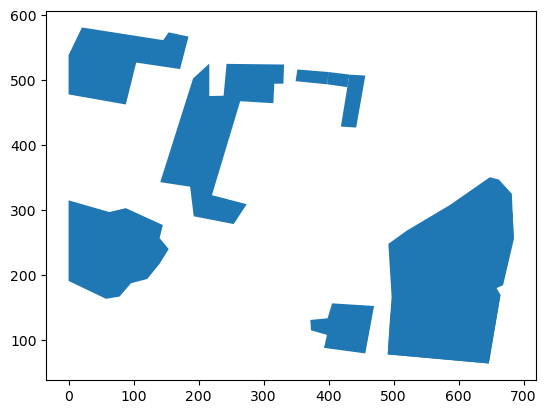

In [4]:
bsm_feat = gpd.read_file("./datasets/sketchmap-bdr-test/basemap.jpg.geojson")
bsm_landmarks  = bsm_feat[bsm_feat['feat_type'] == 'Landmark']


print(bsm_landmarks)
bsm_landmarks.plot()
ax = plt.gca()
ax.set_aspect('equal')

    id  sid isRoute feat_type  selected  aligned    otype  \
22  22  S22     NaN  Landmark     False     True  Polygon   
23  23  S23     NaN  Landmark     False     True  Polygon   
24  24  S24     NaN  Landmark     False     True  Polygon   
25  25  S25     NaN  Landmark     False     True  Polygon   
26  26  S26     NaN  Landmark     False     True  Polygon   
27  27  S27     NaN  Landmark     False     True  Polygon   
28  28  S28     NaN  Landmark     False     True  Polygon   
29  29  S29     NaN  Landmark     False     True  Polygon   
30  30  S30     NaN  Landmark     False     True  Polygon   
31  31  S31     NaN  Landmark     False     True  Polygon   
32  32  S32     NaN  Landmark     False    False  Polygon   

    SketchRouteSeqOrder                                           geometry  
22                  NaN  POLYGON ((58.727 467.5, 94.717 475, 96.217 424...  
23                  NaN  POLYGON ((142.7 397.01, 172.61 392, 190.6 392,...  
24                  NaN  POLYGON ((2

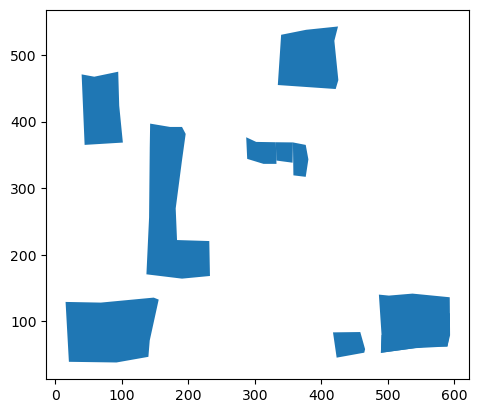

In [5]:
skm_feat = gpd.read_file("./datasets/sketchmap-bdr-test/sketchMap1.JPG.geojson")



skm_landmarks = skm_feat[skm_feat['feat_type'] == 'Landmark']
print(skm_landmarks)
skm_landmarks.plot()
ax = plt.gca()
ax.set_aspect('equal')

In [6]:
with open('./datasets/alignm/alignment.json', 'r') as file:
    align = json.load(file)


print(align['sketchMap1.JPG'])

sketchmap1_align = align['sketchMap1.JPG']

{'1': {'BaseAlign': {'0': [0]}, 'SketchAlign': {'0': ['S0']}, 'genType': 'No generalization', 'degreeOfGeneralization': 0}, '2': {'BaseAlign': {'0': [1]}, 'SketchAlign': {'0': ['S1']}, 'genType': 'No generalization', 'degreeOfGeneralization': 0}, '3': {'BaseAlign': {'0': [2]}, 'SketchAlign': {'0': ['S2']}, 'genType': 'No generalization', 'degreeOfGeneralization': 0}, '4': {'BaseAlign': {'0': [3]}, 'SketchAlign': {'0': ['S3']}, 'genType': 'No generalization', 'degreeOfGeneralization': 0}, '5': {'BaseAlign': {'0': [4]}, 'SketchAlign': {'0': ['S4']}, 'genType': 'No generalization', 'degreeOfGeneralization': 0}, '6': {'BaseAlign': {'0': [6]}, 'SketchAlign': {'0': ['S5']}, 'genType': 'No generalization', 'degreeOfGeneralization': 0}, '7': {'BaseAlign': {'0': [7]}, 'SketchAlign': {'0': ['S6']}, 'genType': 'No generalization', 'degreeOfGeneralization': 0}, '8': {'BaseAlign': {'0': [8]}, 'SketchAlign': {'0': ['S7']}, 'genType': 'No generalization', 'degreeOfGeneralization': 0}, '9': {'BaseAlig

I have three files now: 
        1. Basemap GeoJSON file
        2. Sketchmap GeoJSON file
        3. Alignment JSON file

Alignment file contains how I the landmarks in Basemap are connected to Sketchmap. 

So, there is a key in Sketchmap GeoJSON 'sid' which is mentioned in Alignment file and also an id of Basemap.

This will help us match Landmarks in these files. 

In [7]:
from skimage import transform 
import numpy as np
import sys


base_pts = []
sketch_pts = []
pair_labels = []

for key, value in sketchmap1_align.items():
    if key == "checkAlignnum":
        continue

    base_indices = value['BaseAlign']['0']
    sketch_sids = value['SketchAlign']['0']

    s_id = sketch_sids[0]

    
    s_feat = skm_landmarks[skm_landmarks['sid'] == s_id]
    b_feat = bsm_landmarks[bsm_landmarks['id'].isin(base_indices)]

    if not s_feat.empty and not b_feat.empty:
        s_centroid = s_feat.geometry.representative_point().values[0]
        sketch_pts.append([s_centroid.x, s_centroid.y])

        b_centroids = b_feat.geometry.representative_point()
        mean_x = b_centroids.x.mean()
        mean_y = b_centroids.y.mean()
        base_pts.append([mean_x, mean_y])
#We are using the representative point of the geometry to get a single point for each feature,
#and then we average the x and y coordinates because of generalization of multiple features in teh base map.
#This way we can get a single point for multiple features in the basemap which then aligns with single features in the sketchmap.




X = np.array(base_pts)
Y = np.array(sketch_pts)

tform = transform.SimilarityTransform()
tform.estimate(X,Y)

print("BDR Complete")
print(f" {len(X)} valid alignment pairs.")
print(f" Scale: {tform.scale:.4f}")
print(f" Rotation: {np.degrees(tform.rotation):.2f}")

BDR Complete
 10 valid alignment pairs.
 Scale: 0.8745
 Rotation: 2.01


In the cell above, 

I have taken three lists: 
1. base_pts (stores the points from basemap)
2. sketch_pts (stores the points from sketchmap) and 
3. pair_labels (stores the pairs which are common in basemap and sketchmap)


Then, extract the pairs from the alignment file. 
Where, the common landmarks are matched using, 

'id' from basemap
'sid' from sketchmap

Now, we extract where both id and sid are not empty, giving us the common polygons. 
After this, I take the building id from basemap and sketchmap (they are already aligned) and draw a centroid using the geometry of the buildings in sketchmap.

For basemap, we use representative point, which makes sure the centre point of our building is always inside the building and not out. Since, the buildings in the basemap can have complex shapes, which might include a lot of corners or vertices. 


Then, we store all those points from basemap in X (ground truth), which is the independent variable and 
we store all the points from sketchmap in Y (drawn by user), is the dependent variable. 

WE store them into numpy array, because that is the acceptable format for BDR.


Then we use the SimilarityTransfrom function, which matches how well these two maps match, but movement, rotation and scaling the basemap is allowed to make it fit the sketchmap.


After that, the function find the best rotation, the best scale and the best shift, which results in the smallest possible distrance betweeen the ground truth and the corresponding sketchmaps.

# BDR

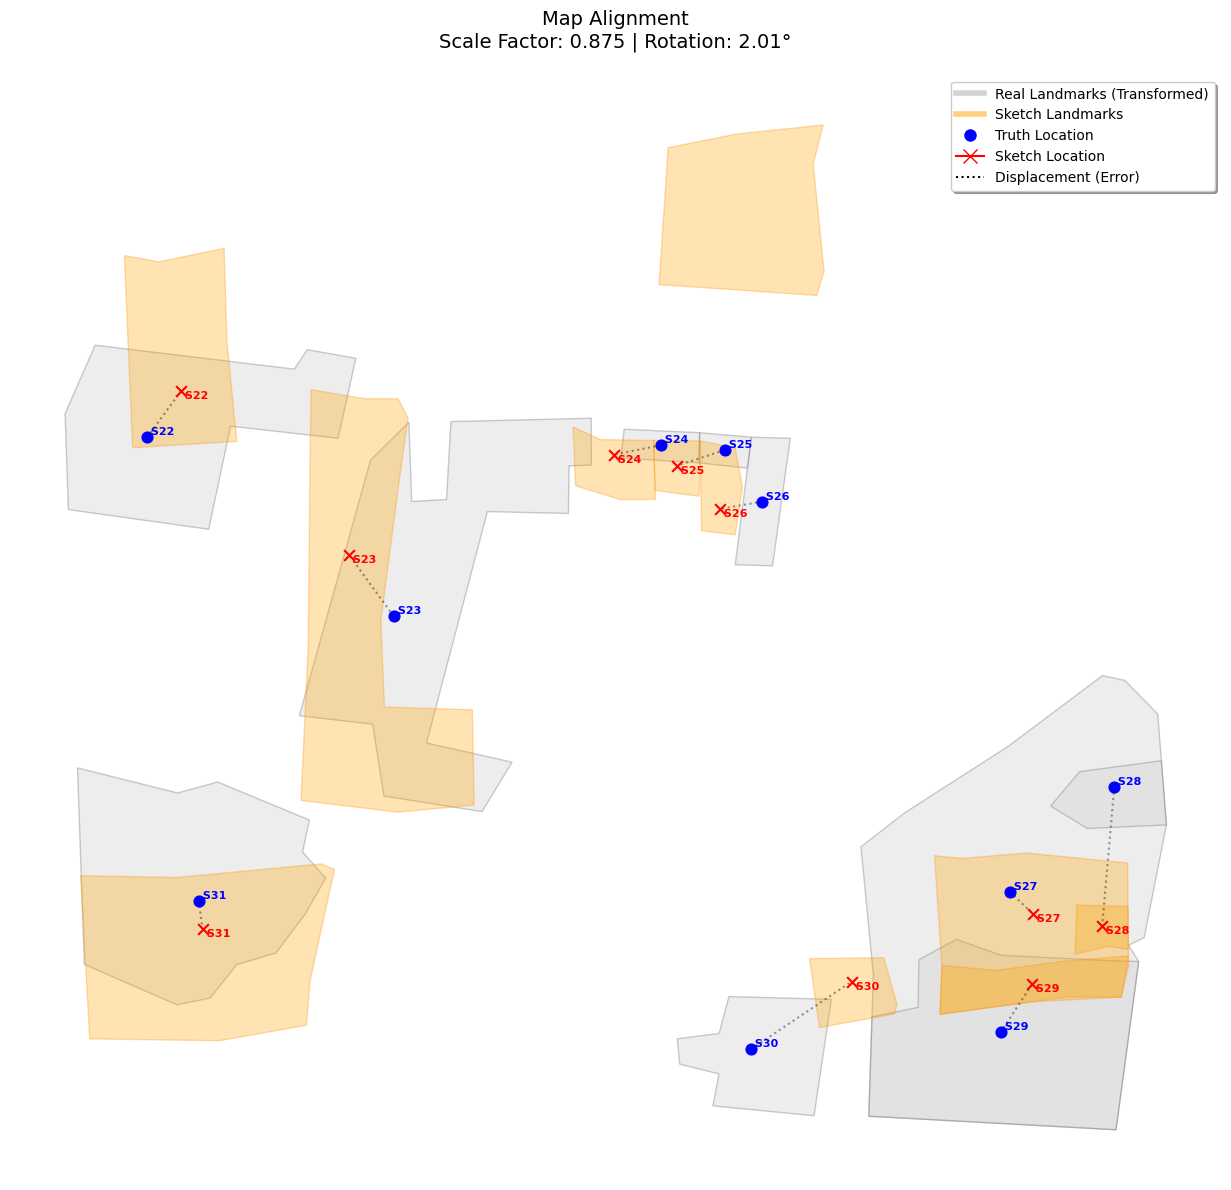

In [8]:
import matplotlib.pyplot as plt
from skimage import transform
from shapely.affinity import affine_transform
import numpy as np

# --- 1. DATA PROCESSING & SYNCHRONIZATION ---
base_pts = []
sketch_pts = []
pair_labels = []

for key, value in sketchmap1_align.items():
    if key == "checkAlignnum": continue
    
    b_indices = value['BaseAlign']['0']
    s_sid = value['SketchAlign']['0'][0]
    
    b_feats = bsm_landmarks[bsm_landmarks['id'].isin(b_indices)]
    s_feat = skm_landmarks[skm_landmarks['sid'] == s_sid]
    
    if not s_feat.empty and not b_feats.empty:
        # Use representative_point to ensure dots stay inside building footprints
        b_point = b_feats.geometry.representative_point()
        base_pts.append([b_point.x.mean(), b_point.y.mean()])
        
        s_point = s_feat.geometry.representative_point().values[0]
        sketch_pts.append([s_point.x, s_point.y])
        pair_labels.append(s_sid) 

X = np.array(base_pts)
Y = np.array(sketch_pts)

# --- 2. BIDIMENSIONAL REGRESSION ---
tform = transform.SimilarityTransform()
tform.estimate(X, Y)
predicted_Y = tform(X)

# --- 3. GEOMETRY TRANSFORMATION ---
# Move the Real Landmarks into Sketch Space so they overlap for the plot
m = tform.params
matrix = [m[0,0], m[0,1], m[1,0], m[1,1], m[0,2], m[1,2]]
bsm_transformed = bsm_landmarks.copy()
bsm_transformed['geometry'] = bsm_transformed['geometry'].apply(lambda x: affine_transform(x, matrix))

# IMPORTANT: Strip CRS to prevent "aspect must be finite" error
bsm_transformed.crs = None
skm_landmarks.crs = None

# --- 4. PLOTTING ---
fig, ax = plt.subplots(figsize=(14, 12))
ax.set_aspect('equal')

# Plot Polygons
bsm_transformed.plot(ax=ax, color='lightgray', edgecolor='gray', alpha=0.4, label='Real World (Projected)')
skm_landmarks.plot(ax=ax, color='orange', edgecolor='darkorange', alpha=0.3, label='User Sketch')

# Plot Dots
# We plot the first one with a label for the legend, then loop the rest
ax.scatter(predicted_Y[:, 0], predicted_Y[:, 1], color='blue', s=60, marker='o', 
           label='Truth Anchor (Blue)', zorder=5)
ax.scatter(Y[:, 0], Y[:, 1], color='red', s=60, marker='x', 
           label='Sketch Anchor (Red)', zorder=5)

# Plot Labels and Connectors
for i in range(len(Y)):
    label = pair_labels[i]
    
    # Label the Blue Dot
    ax.text(predicted_Y[i, 0], predicted_Y[i, 1], f" {label}", 
            color='blue', fontsize=8, fontweight='bold', va='bottom')
    
    # Label the Red Dot
    ax.text(Y[i, 0], Y[i, 1], f" {label}", 
            color='red', fontsize=8, fontweight='bold', va='top')
    
    # Connector line (Error Vector)
    line, = ax.plot([predicted_Y[i, 0], Y[i, 0]], [predicted_Y[i, 1], Y[i, 1]], 
                    color='black', linestyle=':', alpha=0.4, zorder=4)

# Formatting
plt.title(f"Map Alignment\nScale Factor: {tform.scale:.3f} | Rotation: {np.degrees(tform.rotation):.2f}°", 
          fontsize=14, pad=20)

# Manually handle legend because geopandas.plot and ax.scatter work differently
from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0], [0], color='lightgray', lw=4, label='Real Landmarks (Transformed)'),
    Line2D([0], [0], color='orange', lw=4, alpha=0.5, label='Sketch Landmarks'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='blue', markersize=10, label='Truth Location'),
    Line2D([0], [0], marker='x', color='red', markersize=10, label='Sketch Location'),
    Line2D([0], [0], color='black', linestyle=':', label='Displacement (Error)')
]
ax.legend(handles=legend_elements, loc='upper right', frameon=True, shadow=True)

ax.set_axis_off()
plt.tight_layout()
plt.show()

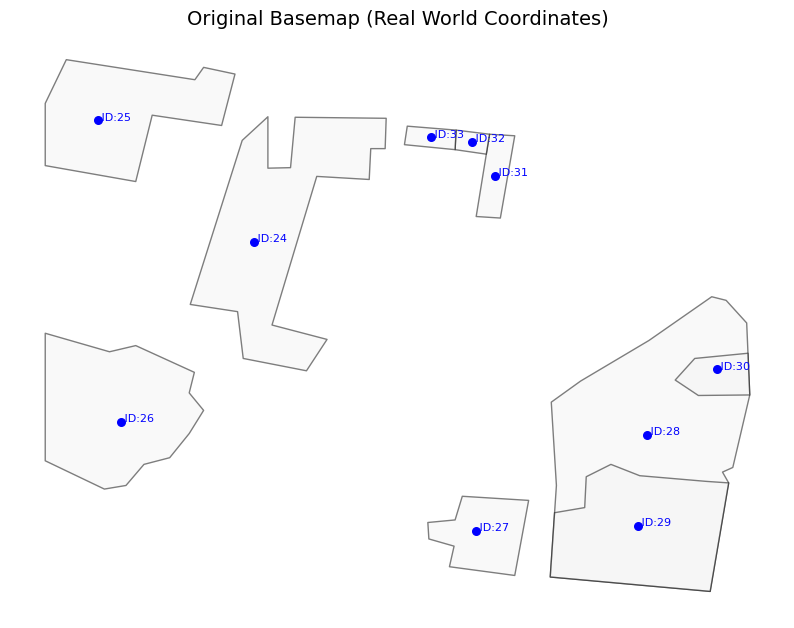

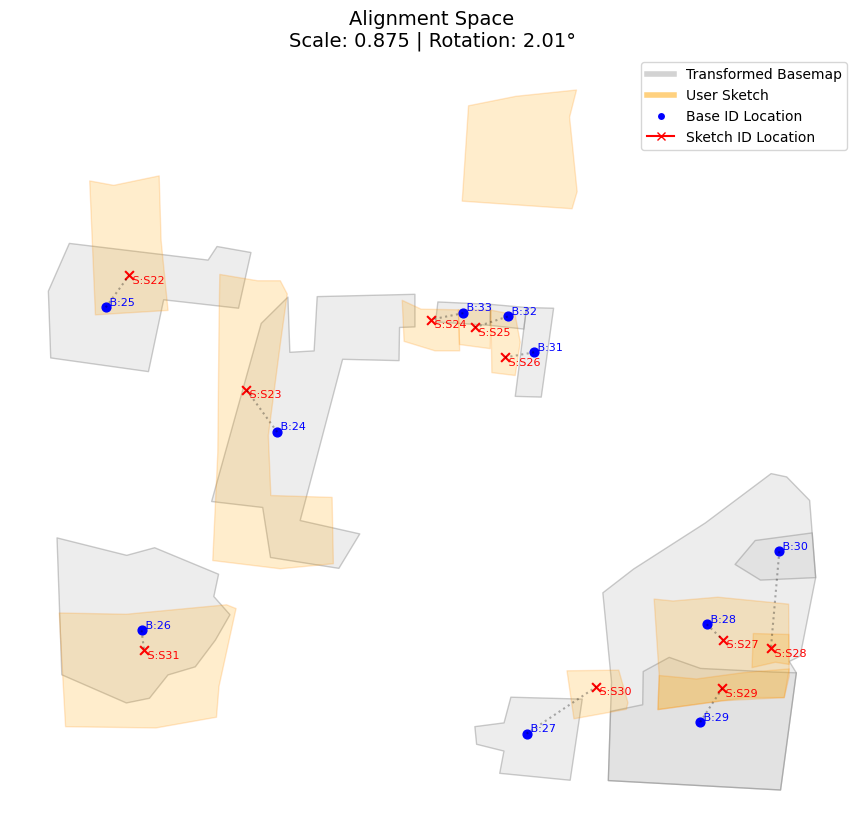

In [9]:
import matplotlib.pyplot as plt
from skimage import transform
from shapely.affinity import affine_transform
import numpy as np
from matplotlib.lines import Line2D

# --- 1. DATA PROCESSING & SYNCHRONIZATION ---
base_pts = []
sketch_pts = []
pair_labels = [] 

for key, value in sketchmap1_align.items():
    if key == "checkAlignnum": continue
    
    b_indices = value['BaseAlign']['0']
    s_sid = value['SketchAlign']['0'][0]
    
    b_feats = bsm_landmarks[bsm_landmarks['id'].isin(b_indices)]
    s_feat = skm_landmarks[skm_landmarks['sid'] == s_sid]
    
    if not s_feat.empty and not b_feats.empty:
        b_point = b_feats.geometry.representative_point()
        base_pts.append([b_point.x.mean(), b_point.y.mean()])
        
        s_point = s_feat.geometry.representative_point().values[0]
        sketch_pts.append([s_point.x, s_point.y])
        pair_labels.append((s_sid, b_indices[0])) 

X = np.array(base_pts)
Y = np.array(sketch_pts)

# --- 2. BIDIMENSIONAL REGRESSION ---
tform = transform.SimilarityTransform()
tform.estimate(X, Y)
predicted_Y = tform(X)

# --- 3. GEOMETRY TRANSFORMATION ---
m = tform.params
matrix = [m[0,0], m[0,1], m[1,0], m[1,1], m[0,2], m[1,2]]
bsm_transformed = bsm_landmarks.copy()
bsm_transformed['geometry'] = bsm_transformed['geometry'].apply(lambda x: affine_transform(x, matrix))

# Clean CRS
bsm_landmarks.crs = None
bsm_transformed.crs = None
skm_landmarks.crs = None

# --- 4. PLOT 1: ORIGINAL BASEMAP ---
fig1, ax1 = plt.subplots(figsize=(10, 8))
bsm_landmarks.plot(ax=ax1, color='whitesmoke', edgecolor='black', alpha=0.5)

# Plot the original base anchor points and their IDs
for i in range(len(X)):
    _, b_id = pair_labels[i]
    ax1.scatter(X[i, 0], X[i, 1], color='blue', s=30)
    ax1.text(X[i, 0], X[i, 1], f" ID:{b_id}", color='blue', fontsize=8)

ax1.set_title("Original Basemap (Real World Coordinates)", fontsize=14)
ax1.set_axis_off()

# --- 5. PLOT 2: ALIGNMENT (SKETCH + TRANSFORMED BASEMAP) ---
fig2, ax2 = plt.subplots(figsize=(12, 10))
ax2.set_aspect('equal')

# Plot Polygons
bsm_transformed.plot(ax=ax2, color='lightgray', edgecolor='gray', alpha=0.4)
skm_landmarks.plot(ax=ax2, color='orange', edgecolor='darkorange', alpha=0.2)

# Plot ID Labels and Error Connectors
for i in range(len(Y)):
    s_id, b_id = pair_labels[i]
    
    # Blue: Transformed Truth | Red: User Sketch
    ax2.scatter(predicted_Y[i, 0], predicted_Y[i, 1], color='blue', s=40, marker='o')
    ax2.scatter(Y[i, 0], Y[i, 1], color='red', s=40, marker='x')
    
    ax2.text(predicted_Y[i, 0], predicted_Y[i, 1], f" B:{b_id}", color='blue', fontsize=8, va='bottom')
    ax2.text(Y[i, 0], Y[i, 1], f" S:{s_id}", color='red', fontsize=8, va='top')
    
    # Connector
    ax2.plot([predicted_Y[i, 0], Y[i, 0]], [predicted_Y[i, 1], Y[i, 1]], color='black', linestyle=':', alpha=0.3)

plt.title(f"Alignment Space\nScale: {tform.scale:.3f} | Rotation: {np.degrees(tform.rotation):.2f}°", fontsize=14)

# Legend
legend_elements = [
    Line2D([0], [0], color='lightgray', lw=4, label='Transformed Basemap'),
    Line2D([0], [0], color='orange', lw=4, alpha=0.5, label='User Sketch'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='blue', label='Base ID Location'),
    Line2D([0], [0], marker='x', color='red', label='Sketch ID Location')
]
ax2.legend(handles=legend_elements, loc='upper right')
ax2.set_axis_off()

plt.show()

In [10]:
print(predicted_Y)

[[ 52.40529418 370.94139498]
 [188.12214348 272.22717864]
 [335.50960321 366.36551031]
 [370.69887399 363.72747514]
 [391.52784253 335.36280937]
 [528.09397878 120.07922856]
 [585.58635892 177.87920562]
 [522.88195487  42.5892063 ]
 [385.50383992  33.48134532]
 [ 80.72515443 115.32888876]]


## Using Centroid to Calculate the BDR

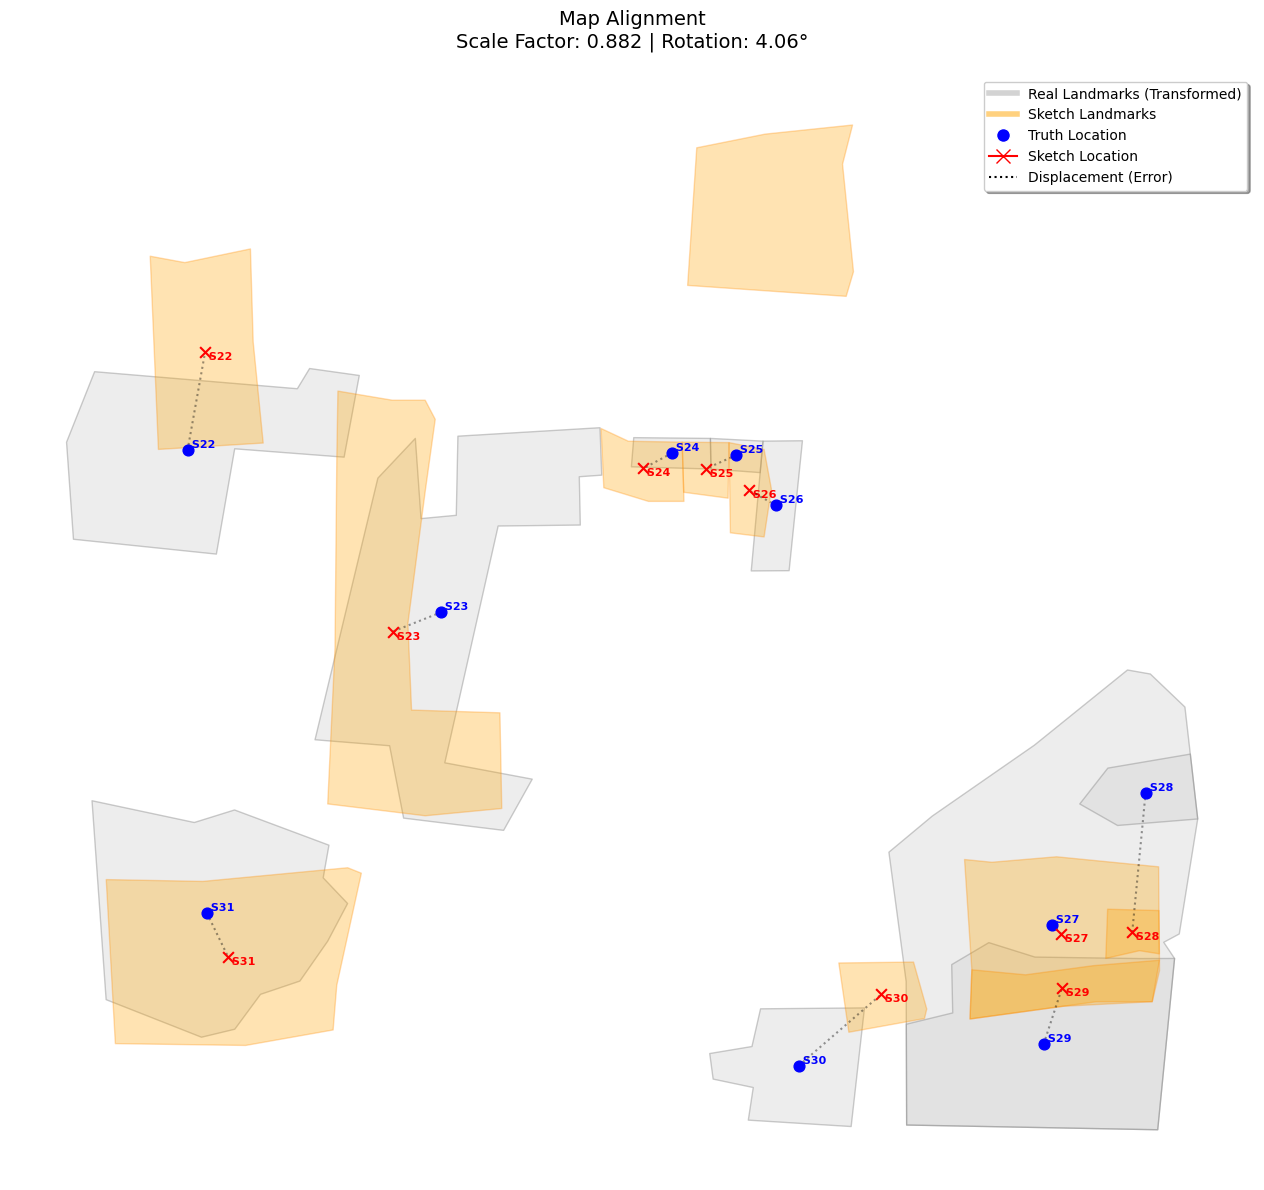

In [11]:
import matplotlib.pyplot as plt
from skimage import transform
from shapely.affinity import affine_transform
import numpy as np

# --- 1. DATA PROCESSING & SYNCHRONIZATION ---
base_pts = []
sketch_pts = []
pair_labels = []

for key, value in sketchmap1_align.items():
    if key == "checkAlignnum": continue
    
    b_indices = value['BaseAlign']['0']
    s_sid = value['SketchAlign']['0'][0]
    
    b_feats = bsm_landmarks[bsm_landmarks['id'].isin(b_indices)]
    s_feat = skm_landmarks[skm_landmarks['sid'] == s_sid]
    
    if not s_feat.empty and not b_feats.empty:
        # Use representative_point to ensure dots stay inside building footprints
        b_point = b_feats.geometry.centroid
        base_pts.append([b_point.x.mean(), b_point.y.mean()])
        
        s_point = s_feat.geometry.centroid.values[0]
        sketch_pts.append([s_point.x, s_point.y])
        pair_labels.append(s_sid) 

X = np.array(base_pts)
Y = np.array(sketch_pts)

# --- 2. BIDIMENSIONAL REGRESSION ---
tform = transform.SimilarityTransform()
tform.estimate(X, Y)
predicted_Y = tform(X)

# --- 3. GEOMETRY TRANSFORMATION ---
# Move the Real Landmarks into Sketch Space so they overlap for the plot
m = tform.params
matrix = [m[0,0], m[0,1], m[1,0], m[1,1], m[0,2], m[1,2]]
bsm_transformed = bsm_landmarks.copy()
bsm_transformed['geometry'] = bsm_transformed['geometry'].apply(lambda x: affine_transform(x, matrix))

# IMPORTANT: Strip CRS to prevent "aspect must be finite" error
bsm_transformed.crs = None
skm_landmarks.crs = None

# --- 4. PLOTTING ---
fig, ax = plt.subplots(figsize=(14, 12))
ax.set_aspect('equal')

# Plot Polygons
bsm_transformed.plot(ax=ax, color='lightgray', edgecolor='gray', alpha=0.4, label='Real World (Projected)')
skm_landmarks.plot(ax=ax, color='orange', edgecolor='darkorange', alpha=0.3, label='User Sketch')

# Plot Dots
# We plot the first one with a label for the legend, then loop the rest
ax.scatter(predicted_Y[:, 0], predicted_Y[:, 1], color='blue', s=60, marker='o', 
           label='Truth Anchor (Blue)', zorder=5)
ax.scatter(Y[:, 0], Y[:, 1], color='red', s=60, marker='x', 
           label='Sketch Anchor (Red)', zorder=5)

# Plot Labels and Connectors
for i in range(len(Y)):
    label = pair_labels[i]
    
    # Label the Blue Dot
    ax.text(predicted_Y[i, 0], predicted_Y[i, 1], f" {label}", 
            color='blue', fontsize=8, fontweight='bold', va='bottom')
    
    # Label the Red Dot
    ax.text(Y[i, 0], Y[i, 1], f" {label}", 
            color='red', fontsize=8, fontweight='bold', va='top')
    
    # Connector line (Error Vector)
    line, = ax.plot([predicted_Y[i, 0], Y[i, 0]], [predicted_Y[i, 1], Y[i, 1]], 
                    color='black', linestyle=':', alpha=0.4, zorder=4)

# Formatting
plt.title(f"Map Alignment\nScale Factor: {tform.scale:.3f} | Rotation: {np.degrees(tform.rotation):.2f}°", 
          fontsize=14, pad=20)

# Manually handle legend because geopandas.plot and ax.scatter work differently
from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0], [0], color='lightgray', lw=4, label='Real Landmarks (Transformed)'),
    Line2D([0], [0], color='orange', lw=4, alpha=0.5, label='Sketch Landmarks'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='blue', markersize=10, label='Truth Location'),
    Line2D([0], [0], marker='x', color='red', markersize=10, label='Sketch Location'),
    Line2D([0], [0], color='black', linestyle=':', label='Displacement (Error)')
]
ax.legend(handles=legend_elements, loc='upper right', frameon=True, shadow=True)

ax.set_axis_off()
plt.tight_layout()
plt.show()

In [12]:
print(predicted_Y)

[[ 60.18819459 364.48290553]
 [199.49927079 275.72961614]
 [325.94480734 363.00578897]
 [361.25224289 361.88134909]
 [383.3190539  334.28498736]
 [534.39738703 104.19690968]
 [585.82395117 176.71659798]
 [529.87206358  38.72237661]
 [395.5289252   26.96816372]
 [ 70.86419751 110.5644909 ]]


## DI (Distortion Index)

In [13]:
import sklearn.metrics
r2 = sklearn.metrics.r2_score(Y, predicted_Y)
distortion_index = 100 * np.sqrt(1 - r2)
print((f"R²: {r2:.4f}"))
print((f"Distortion Index: {distortion_index:.2f}"))

R²: 0.9611
Distortion Index: 19.71


## Translation

In [14]:
alpha1 = tform.translation[0]
alpha2 = tform.translation[1]
print(f"Alpha 1 (X-Shift): {alpha1:.2f}")
print(f"Alpha 2 (Y-Shift): {alpha2:.2f}")

Alpha 1 (X-Shift): 27.50
Alpha 2 (Y-Shift): -105.22


## Correlation Coefficient (r)

In [15]:
from sklearn.metrics import r2_score
r2 = r2_score(Y, predicted_Y)
r = np.sqrt(r2)
print(f"Bidimensional Correlation (r): {r:.4f}")

Bidimensional Correlation (r): 0.9804


## Rotation 

In [16]:
# Convert radians to degrees
rotation_deg = np.degrees(tform.rotation)
print(f"Rotation (Theta): {rotation_deg:.2f}°")

Rotation (Theta): 4.06°


In [17]:
import pandas as pd
bdr_self = pd.DataFrame({
    'Alpha 1 (X)': alpha1,
    'Alpha 2 (Y)': alpha2,
    'Scale': tform.scale,
    'Rotation (Degrees)': rotation_deg,
    'R²': r2,
    'Distortion Index': distortion_index,
    'Correlation (r)': r,
}, index=[0]) 

bdr_GMDA = pd.DataFrame({
    'Alpha 1 (X)': -333.209,
    'Alpha 2 (Y)': -320.117,
    'Scale': 0.722,
    'Rotation (Degrees)': 1.944,
    'R²': 0.0,
    'Distortion Index': 18.218,
    'Correlation (r)': 0.983,
}, index=[0])

# 1. Combine the dataframes (make sure they have an index as discussed before)
# We transpose them (.T) so metrics are vertical for easier comparison
comparison = pd.concat([bdr_self.T, bdr_GMDA.T], axis=1)

# 2. Rename columns for clarity
comparison.columns = ['Your Calculation', 'GMDA Software']

# 3. Add a Difference column to check for precision
comparison['Difference'] = comparison['Your Calculation'] - comparison['GMDA Software']

# Display the comparison
print(comparison)

                    Your Calculation  GMDA Software  Difference
Alpha 1 (X)                27.500086       -333.209  360.709086
Alpha 2 (Y)              -105.220186       -320.117  214.896814
Scale                       0.882302          0.722    0.160302
Rotation (Degrees)          4.060852          1.944    2.116852
R²                          0.961143          0.000    0.961143
Distortion Index           19.712191         18.218    1.494191
Correlation (r)             0.980379          0.983   -0.002621


# GARDONY BASED - MEASURES

## Canonical Measures


### Canonical Score

In [18]:
import pandas as pd
import itertools


def calc_bas_can_score(X, Y, total_landmarks):
    """ 
    Calculates the Canonical Score (N/S and E/W relation)
    Parameters: 
    - X: np.array of Ground Truth coordinates (Base)
    - Y: np.array of Sketch coordinates
    - total_landmarks: int, total number of landmarks

    Returns: 
    - score: float( 0 to 100)
    """

    #Number of Landmarks in the Target Environment (Sketchmap)

    nTL = len(X)

    #Each landmark pair has 2 dimnesions (N/S and E/W)
    #Total comparisons = n * (n - 1) / 2   

    total_pairs_in_study = (total_landmarks * (total_landmarks - 1)) // 2

    max_possible_points = total_pairs_in_study * 2

    points_earned = 0

    if nTL < 2:
        return 0.0
    
    for i, j in itertools.combinations(range(nTL), 2):
        # 1. Calculate relative vectors for BaseMap (Truth)
        base_dx = X[j, 0] - X[i, 0] 
        base_dy = X[j, 1] - X[i, 1] 


        # 2. Calculate relative vectors for SketchMap 
        sketch_dx = Y[j, 0] - Y[i, 0] 
        sketch_dy = Y[j, 1] - Y[i, 1] 


        # Step 1 & 2: Check the N/S dimension 
        # use np.sign to see if the vertical direction is the same
        # (-1 for South, +1 for North, 0 for perfectly aligned)
        if np.sign(base_dy) == np.sign(sketch_dy):
            points_earned += 1

        #Step 4: E/W dimension check 
        # (-1 for West, +1 for East, 0 for perfectly aligned)
        if np.sign(base_dx) == np.sign(sketch_dx):
            points_earned += 1

    # Step 3: Logic is handled here: point_earned is only tallied here or summed up

    score = points_earned

    return score

In [19]:
import pandas as pd
import numpy as np
import itertools
import math

def calc_adv_canonical_score(base_csv, sketch_csv):
    # 1. Load Data
    base_df = pd.read_csv(base_csv)
    sketch_df = pd.read_csv(sketch_csv)

    # 2. Alignment
    # Ensure we only compare points that exist in both files 
    # based on Landmark ID and Rectangle Vertex ID
    merged = pd.merge(
        base_df, sketch_df, 
        on=['landmarkName', 'rectangleVertexNum'], 
        suffixes=('_base', '_sketch')
    )

    # Convert to arrays for speed
    base_coords = merged[['X_base', 'Y_base']].values
    sketch_coords = merged[['X_sketch', 'Y_sketch']].values
    landmark_ids = merged['landmarkName'].values
    
    n_total_points = len(merged)
    nTL = merged['landmarkName'].nunique() # Number of unique landmarks

    points_earned = 0
    comparisons_count = 0

    # 3. Vertex-to-Vertex Comparison Loop
    # Compare every point i with every point j
    for i, j in itertools.combinations(range(n_total_points), 2):
        
        # SKIP if the points belong to the same landmark
        if landmark_ids[i] == landmark_ids[j]:
            continue
            
        comparisons_count += 1
        
        # Calculate relative direction in Basemap
        base_dx = base_coords[j, 0] - base_coords[i, 0]
        base_dy = base_coords[j, 1] - base_coords[i, 1]
        
        # Calculate relative direction in Sketchmap
        sketch_dx = sketch_coords[j, 0] - sketch_coords[i, 0]
        sketch_dy = sketch_coords[j, 1] - sketch_coords[i, 1]
        
        # Check N/S
        if np.sign(base_dy) == np.sign(sketch_dy):
            points_earned += 1
            
        # Check E/W
        if np.sign(base_dx) == np.sign(sketch_dx):
            points_earned += 1

    # 4. Final Organization Score
    # The max possible points is comparisons_count * 2 (one for X, one for Y)
    if comparisons_count == 0:
        return 0.0
        
    can_score = points_earned
    
    return can_score, comparisons_count

# Example call:
# score = calc_advanced_canonical_score('basemap.csv', 'sketchmap.csv')
# print(f"Advanced Canonical Organization: {score:.4f}")

In [20]:
base_csv = r"datasets\rectangle_coords\rect_coords_basemap.csv"
sketch_csv = r"datasets\rectangle_coords\rect_coords_skm1.csv"
score, comps = calc_adv_canonical_score(base_csv, sketch_csv)
print(score, comps)

5460 2880


### Canonical Organization (CanOrg)

In [21]:
import math
def calc_can_org(can_score, nTL, method):
    """ 
    CanOrg = CanScore / 2*total_landmarks 
    """

    if method == "basic":
        basic_n = math.comb(nTL, 2) #here nTL = total landmarks in Target Environment (Basemap)

        can_org = can_score / (2 * basic_n)
        return can_org
    
    elif method == "advanced":
        advanced_n = math.comb(8 * nTL, 2) - (nTL * math.comb(8,2)) 

        can_org = can_score / (2 * advanced_n)

        return can_org 
    
    else:
        return "Invalid method specified. Choose 'basic' or 'advanced'." 
        


In [22]:
calc_can_org(can_score= score, nTL = len(X), method = "advanced")

0.9479166666666666

### Canonical Accuracy


In [23]:
def calc_can_acc(can_score, nDL, method):
    """ 
    CanAcc = CanScore / 2*total_landmarks 
    """

    if method == "basic":
        basic_n = math.comb(nDL, 2) #here nDL = total landmarks in Design Environment (Sketch)

        can_acc = can_score / (2 * basic_n)
        return can_acc
    
    elif method == "advanced":
        advanced_n = math.comb(8 * nDL, 2) - (nDL * math.comb(8,2)) 

        can_acc = can_score / (2 * advanced_n)

        return can_acc 
    
    else:
        return "Invalid method specified. Choose 'basic' or 'advanced'."

In [24]:
calc_can_acc(can_score= calc_bas_can_score(X, Y, total_landmarks = len(X)), nDL = len(X), method = "basic")

0.9555555555555556

# Rotational Bias

In [140]:
import pandas as pd
import numpy as np

import pandas as pd
import numpy as np

def get_centroids(df):
    return df.groupby('landmarkName').agg({'X': 'mean', 'Y': 'mean'}).to_dict('index')

def calc_rotational_bias(sketch_df, base_df, mode):
    sum_sin, sum_cos = 0.0, 0.0
    num_comps = 0
    
    if mode == "basic":
        sm_pts = get_centroids(sketch_df)
        bm_pts = get_centroids(base_df)
        landmarks = sorted(list(sm_pts.keys())) # Sort to ensure consistent pairing
        
        for i in range(len(landmarks)):
            for j in range(i + 1, len(landmarks)):
                l1, l2 = landmarks[i], landmarks[j]
                
                # Gardony standard: atan2(delta_x, delta_y)
                ang_bm = np.arctan2(bm_pts[l2]['X'] - bm_pts[l1]['X'], 
                                   bm_pts[l2]['Y'] - bm_pts[l1]['Y'])
                ang_sm = np.arctan2(sm_pts[l2]['X'] - sm_pts[l1]['X'], 
                                   sm_pts[l2]['Y'] - sm_pts[l1]['Y'])
                
                # Difference in orientation for this specific pair
                diff = ang_sm - ang_bm
                
                sum_sin += np.sin(diff)
                sum_cos += np.cos(diff)
                num_comps += 1

    elif mode == "advanced":
        landmarks = sorted(sketch_df['landmarkName'].unique())
        
        for i in range(len(landmarks)):
            for j in range(i + 1, len(landmarks)):
                l1_name, l2_name = landmarks[i], landmarks[j]
                
                l1_sm = sketch_df[sketch_df['landmarkName'] == l1_name].set_index('rectangleVertexNum')
                l2_sm = sketch_df[sketch_df['landmarkName'] == l2_name].set_index('rectangleVertexNum')
                l1_bm = base_df[base_df['landmarkName'] == l1_name].set_index('rectangleVertexNum')
                l2_bm = base_df[base_df['landmarkName'] == l2_name].set_index('rectangleVertexNum')

                for v1 in l1_sm.index:
                    for v2 in l2_sm.index:
                        ang_bm = np.arctan2(l2_bm.loc[v2, 'X'] - l1_bm.loc[v1, 'X'], 
                                           l2_bm.loc[v2, 'Y'] - l1_bm.loc[v1, 'Y'])
                        ang_sm = np.arctan2(l2_sm.loc[v2, 'X'] - l1_sm.loc[v1, 'X'], 
                                           l2_sm.loc[v2, 'Y'] - l1_sm.loc[v1, 'Y'])
                        
                        diff = ang_sm - ang_bm
                        sum_sin += np.sin(diff)
                        sum_cos += np.cos(diff)
                        num_comps += 1

    if num_comps == 0: return 0.0

    # Calculate average components
    avg_sin = sum_sin / num_comps
    avg_cos = sum_cos / num_comps
    
    # Final Bias
    rot_bias = np.degrees(np.arctan2(avg_sin, avg_cos))
    return rot_bias
# --- Usage ---
sketch_df = pd.read_csv(r'datasets\rectangle_coords\rect_coords_skm1.csv')
base_df = pd.read_csv(r'datasets\rectangle_coords\rect_coords_basemap.csv')

basic_bias = calc_rotational_bias(sketch_df, base_df, "basic")
adv_bias = calc_rotational_bias(sketch_df, base_df, "advanced")

print(f"Rotational Bias (Basic): {basic_bias:.2f}°")
print(f"Rotational Bias (Advanced): {adv_bias:.2f}°")

Rotational Bias (Basic): -2.39°
Rotational Bias (Advanced): -3.61°


rot bias basic = -0.18 
rot bias advanced = -3.28

software results 
rot  bias basic = -1.12
rot bias advanced = -3.61

In [42]:
print(Y)

[[ 69.81439424 418.24099079]
 [172.74045636 265.0579359 ]
 [310.25038228 354.54506631]
 [344.73043141 354.49132716]
 [368.06523955 342.57925216]
 [539.45812856  99.354174  ]
 [578.4935796  100.27037703]
 [539.8931124   69.35427463]
 [440.76222831  66.05449678]
 [ 82.4821413   86.60529121]]


# Angular Accuracy

To calculate the Angular Accuracy, we need to caclulate three things

1. angSM (angle of sketchmap pair) = atan2(L2_sm_x - L1_sm_x, L2_sm_y - L1_sm_y)
2. angBM (angle of basemap pair) = atan2(L2_bm_x - L1_bm_x, L2_bm_y - L1_bm_y)
3. angDIFF (difference between angles) = angSM - angBM

All of the above metrics are measured in radians.


In [117]:
import pandas as pd
import numpy as np
import math

def calculate_centroid(group):
    """Calculates the center point of a set of vertices."""
    return pd.Series({
        'X': group['X'].mean(),
        'Y': group['Y'].mean()
    })

def get_bearing(p1, p2):
    """Calculates bearing in radians between two points (X1, Y1) and (X2, Y2)."""
    return math.atan2(p2['X'] - p1['X'], p2['Y'] - p1['Y'])

def calc_an_acc(sketch_df, base_df, mode):
    running_angle_diff = 0.0
    num_comps = 0

    if mode == "basic":
        # Reduce each landmark to a single point (centroid)
        sm_points = sketch_df.groupby('landmarkName').apply(calculate_centroid, include_groups=False)
        bm_points = base_df.groupby('landmarkName').apply(calculate_centroid, include_groups=False)
        
        landmarks = sm_points.index.tolist()
        
        for i in range(len(landmarks)):
            for j in range(i + 1, len(landmarks)):
                l1, l2 = landmarks[i], landmarks[j]
                
                ang_sm = get_bearing(sm_points.loc[l1], sm_points.loc[l2])
                ang_bm = get_bearing(bm_points.loc[l1], bm_points.loc[l2])
                
                diff_rad = (ang_sm - ang_bm + math.pi) % (2 * math.pi) - math.pi
                running_angle_diff += abs(math.degrees(diff_rad))
                num_comps += 1

    elif mode == "advanced":
        # Compare every vertex of Landmark A to every vertex of Landmark B
        landmarks = sketch_df['landmarkName'].unique()
        
        for i in range(len(landmarks)):
            for j in range(i + 1, len(landmarks)):
                l1_name, l2_name = landmarks[i], landmarks[j]
                
                # Get all vertices for these two landmarks
                l1_sm = sketch_df[sketch_df['landmarkName'] == l1_name]
                l2_sm = sketch_df[sketch_df['landmarkName'] == l2_name]
                l1_bm = base_df[base_df['landmarkName'] == l1_name]
                l2_bm = base_df[base_df['landmarkName'] == l2_name]

                # Nested loop through vertices (0-7 for each)
                for idx1 in l1_sm.index:
                    for idx2 in l2_sm.index:
                        # Ensure we are comparing the same rectangleVertexNum
                        p1_sm, p2_sm = l1_sm.loc[idx1], l2_sm.loc[idx2]
                        p1_bm, p2_bm = l1_bm.loc[idx1], l2_bm.loc[idx2]

                        ang_sm = get_bearing(p1_sm, p2_sm)
                        ang_bm = get_bearing(p1_bm, p2_bm)

                        diff_rad = (ang_sm - ang_bm + math.pi) % (2 * math.pi) - math.pi
                        running_angle_diff += abs(math.degrees(diff_rad))
                        num_comps += 1

    if num_comps == 0:
        return 0

    # Final Accuracy: 1 - (Mean Absolute Error / Max Possible Error)
    mean_error = running_angle_diff / num_comps
    return 1.0 - (mean_error / 180.0)

# --- Execution ---
# Load your data
sketch_df = pd.read_csv(r'datasets\rectangle_coords\rect_coords_skm1.csv')
base_df = pd.read_csv(r'datasets\rectangle_coords\rect_coords_basemap.csv')

basic_acc = calc_an_acc(sketch_df, base_df, "basic")
adv_acc = calc_an_acc(sketch_df, base_df, "advanced")

print(f"Basic Mode Accuracy (Centroids): {basic_acc:.4f}")
print(f"Advanced Mode Accuracy (All Vertices): {adv_acc:.4f}")

Basic Mode Accuracy (Centroids): 0.9408
Advanced Mode Accuracy (All Vertices): 0.9349


basic mode = 0.95 
advanced mode = 0.93

# Building Pipeline for BDR and  GMDA- based measures

1. Extract Polygons from GeoJSON files
2. Draw minimum bounding box
3. Extract 8 points for each landmark/polygon
4. Calculate the BDR and GMDA-based measures


## 1. Extract Polygons from GeoJSON files 


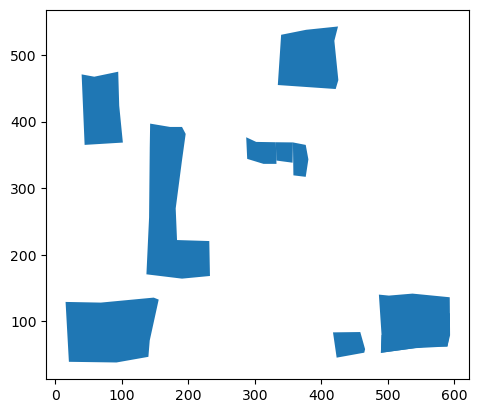

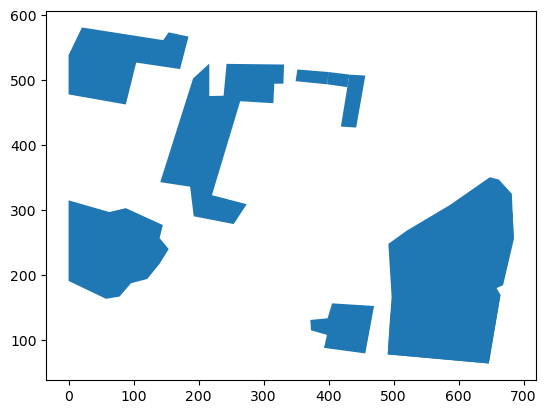

In [41]:
import geopandas as gpd
import json
import matplotlib.pyplot as plt

#Extracting all the landmarks from the basemap 
bsm_feat = gpd.read_file("./datasets/sketchmap-bdr-test/basemap.jpg.geojson")
bsm_landmarks  = bsm_feat[bsm_feat['feat_type'] == 'Landmark']


#Extracting all the landmarks from the sketchmap.
skm_feat = gpd.read_file("./datasets/sketchmap-bdr-test/sketchmap1.JPG.geojson")
skm_landmarks = skm_feat[(skm_feat['feat_type'] == 'Landmark') | (skm_feat['otype'] == 'CircleMarker')]

#Plotting to see the landmarks in both maps.
skm_landmarks.plot(aspect = 'equal')
bsm_landmarks.plot()
ax = plt.gca()
ax.set_aspect('equal')

## 2. Draw a Minimum Bounding box for each of the Landmarks

<Axes: >

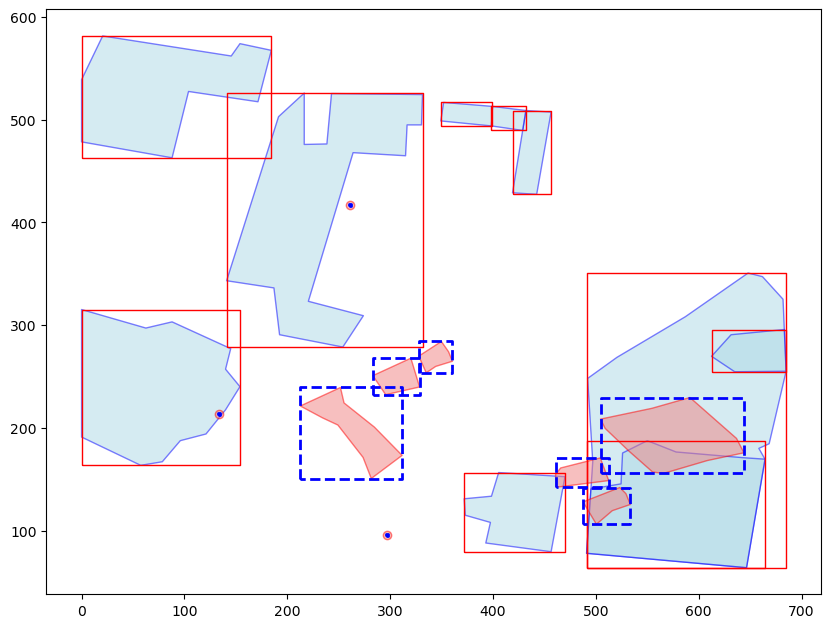

In [31]:
import geopandas as gpd

# 1. Load your data
bsm_gdf = gpd.GeoDataFrame.from_features(bsm_landmarks) # for basemap landmarks
skm_gdf = gpd.GeoDataFrame.from_features(skm_landmarks) # for sketchmap landmarks

buffer_size = 1
# 2. Explicitly create the bounding boxes as a GeoSeries
# This ensures GeoPandas knows these are geometries from the start
bsm_gdf['tight_bbox'] = bsm_gdf.geometry.apply(
    lambda g: g.buffer(buffer_size).envelope if g.geom_type == 'Point' else g.envelope
) # fpr basemap landmarks
skm_gdf['tight_bbox'] = skm_gdf.geometry.apply(
    lambda s: s.buffer(buffer_size).envelope if s.geom_type == 'Point' else s.envelope
) # for sketchmap landmarks


# 3. Plotting
# We use .geometry.boundary to get just the outlines of the original shapes
ax = bsm_gdf.geometry.plot(color='lightblue', edgecolor='blue', alpha=0.5, figsize=(10, 10))
ax = skm_gdf.geometry.plot(ax=ax, color='lightcoral', edgecolor='red', alpha=0.5)

# Now set_geometry should work because 'tight_bbox' is a proper GeoSeries
bsm_gdf.set_geometry('tight_bbox').boundary.plot(ax=ax, color='red', linewidth=1, label = 'BSM_BBOX')
skm_gdf.set_geometry('tight_bbox').boundary.plot(ax=ax, color='blue', linewidth=2, linestyle = '--', label = 'SKM BBOX')

In [21]:
minx, miny, maxx, maxy = skm_gdf.total_bounds
print(f"Map Width: {maxx - minx}")

Map Width: 510.630495


## 3. Extract 8-points each for every polygon

In [32]:
from shapely.geometry import Point 
import numpy as np


def extract_bbox(geometry):
    """ Extracts the bounding box of a geometry and returns it the vertices and midpoints """
    coords = list(geometry.exterior.coords)

    v = coords[:4]  # Assuming the first 4 points are the vertices

    midpoints = []

    for i in range(4):
        p1 = coords[i]
        p2 = coords[i + 1]

        mid = ((p1[0] + p2[0]) / 2, (p1[1] + p2[1]) / 2)
        midpoints.append(mid)

    return v, midpoints


#applying the function to the 'tight_bbox' colums to extract vertices and midpoints 
results_bsm = bsm_gdf['tight_bbox'].apply(extract_bbox)
results_skm = skm_gdf['tight_bbox'].apply(extract_bbox)


#Storing the vertices and midpoints in separate columns for easier access
#For basemap
bsm_gdf['vertices'] = results_bsm.apply(lambda x : x[0])
bsm_gdf['midpoints'] = results_bsm.apply(lambda x : x[1])

#For sketchmap
skm_gdf['vertices'] = results_skm.apply(lambda x : x[0])
skm_gdf['midpoints'] = results_skm.apply(lambda x : x[1])

# print("Vertices of the first polygon:", bsm_gdf['vertices'].iloc[0])
# print("Midpoints of the first polygon:", bsm_gdf['midpoints'].iloc[0])

# print("Vertices of the first polygon in Sketchmap:", skm_gdf['vertices'].iloc[0])
# print("Midpoints of the first polygon in Sketchmap:", skm_gdf['midpoints'].iloc[0])

X = []
for _, row in bsm_gdf.sort_values('id').iterrows():
    X.extend(row['vertices'] + row['midpoints'])

Y = []
for _, row in skm_gdf.sort_values('id').iterrows():
    Y.extend(row['vertices'] + row['midpoints'])


ids = np.repeat(bsm_gdf.sort_values('id')['id'].values, 8)

print(X)


[(141.0, 278.800003), (331.5, 278.800003), (331.5, 525.800003), (141.0, 525.800003), (236.25, 278.800003), (331.5, 402.30000299999995), (236.25, 525.800003), (141.0, 402.30000299999995), (0.0, 462.800003), (184.5, 462.800003), (184.5, 581.300003), (0.0, 581.300003), (92.25, 462.800003), (184.5, 522.050003), (92.25, 581.300003), (0.0, 522.050003), (0.0, 163.800003), (154.0, 163.800003), (154.0, 315.300003), (0.0, 315.300003), (77.0, 163.800003), (154.0, 239.550003), (77.0, 315.300003), (0.0, 239.550003), (372.0, 79.800003), (470.0, 79.800003), (470.0, 156.800003), (372.0, 156.800003), (421.0, 79.800003), (470.0, 118.300003), (421.0, 156.800003), (372.0, 118.300003), (491.0, 64.300003), (685.0, 64.300003), (685.0, 350.800003), (491.0, 350.800003), (588.0, 64.300003), (685.0, 207.550003), (588.0, 350.800003), (491.0, 207.550003), (491.0, 64.300003), (664.5, 64.300003), (664.5, 187.800003), (491.0, 187.800003), (577.75, 64.300003), (664.5, 126.050003), (577.75, 187.800003), (491.0, 126.050

<Axes: >

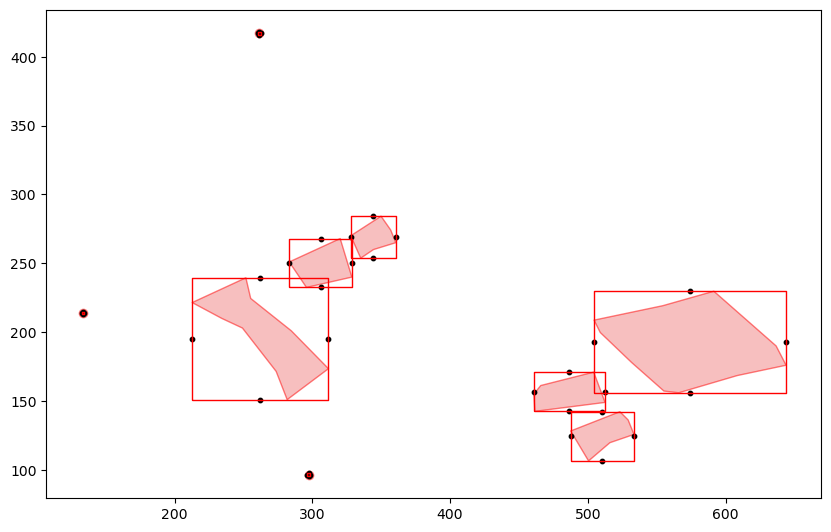

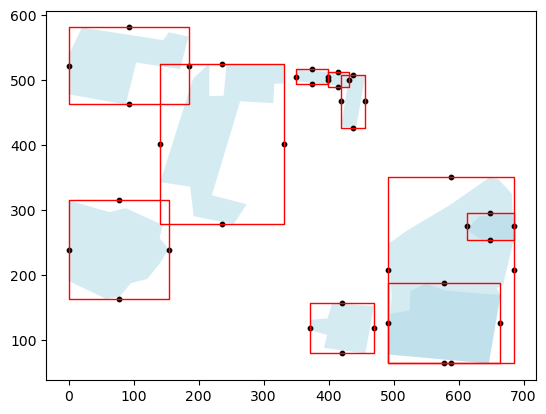

In [33]:
# Flatten the list of midpoints into a list of Shapely Points for plotting
all_mids_bsm = [Point(p) for sublist in bsm_gdf['midpoints'] for p in sublist]
mids_gs_bsm = gpd.GeoSeries(all_mids_bsm)

all_mids_skm = [Point(p) for sublist in skm_gdf['midpoints'] for p in sublist]
mids_gs_skm = gpd.GeoSeries(all_mids_skm)

ax = skm_gdf.geometry.plot(color='lightcoral', edgecolor='red', alpha=0.5, figsize=(10, 10))
skm_gdf.set_geometry('tight_bbox').boundary.plot(ax=ax, color='red', linewidth=1)
mids_gs_skm.plot(ax=ax, color='black', markersize=10) # Black dots at midpoints
ax = bsm_gdf.geometry.plot(color='lightblue', alpha=0.5)
bsm_gdf.set_geometry('tight_bbox').boundary.plot(ax=ax, color='red', linewidth=1)
mids_gs_bsm.plot(ax=ax, color='black', markersize=10) # Black dots at midpoints


In [37]:
with open('./datasets/alignm/alignment.json', 'r') as file:
    align = json.load(file)


print(align['sketchMap8.JPG'])

sketchmap1_align = align['sketchMap1.JPG']

# --- 1. DATA PROCESSING & SYNCHRONIZATION ---
base_pts = []
sketch_pts = []
pair_labels = []

for key, value in sketchmap1_align.items():
    if key == "checkAlignnum": continue
    
    b_indices = value['BaseAlign']['0']
    s_sid = value['SketchAlign']['0'][0]
    
    b_feats = bsm_gdf[bsm_gdf['id'].isin(b_indices)]
    s_feat = skm_gdf[skm_gdf['sid'] == s_sid]
    
    if not s_feat.empty and not b_feats.empty:
        # Use representative_point to ensure dots stay inside building footprints
        b_point = b_feats.geometry.centroid
        base_pts.append([b_point.x.mean(), b_point.y.mean()])
        
        s_point = s_feat.geometry.centroid
        sketch_pts.append([s_point.x, s_point.y])
        pair_labels.append(s_sid) 

X_basic = np.array(base_pts)
Y_basic = np.array(sketch_pts)


# --- ADVANCED DATA PROCESSING ---
base_pts_adv = []
sketch_pts_adv = []
ids_adv = []

for key, value in sketchmap1_align.items():
    if key == "checkAlignnum": continue
    
    b_indices = value['BaseAlign']['0']
    s_sid = value['SketchAlign']['0'][0]
    
    # Extract the first matching feature for geometry points
    b_feat = bsm_gdf[bsm_gdf['id'].isin(b_indices)]
    s_feat = skm_gdf[skm_gdf['sid'] == s_sid]
    
    if not s_feat.empty and not b_feat.empty:
        # Take the first row if multiple buildings match (common in many-to-one)
        b_row = b_feat.iloc[0]
        s_row = s_feat.iloc[0]
        
        # 1. Collect the 8 points (4 vertices + 4 midpoints)
        # Assuming you already ran the extract_bbox code to create these columns
        b_8 = b_row['vertices'] + b_row['midpoints']
        s_8 = s_row['vertices'] + s_row['midpoints']
        
        # 2. Append to our advanced lists
        base_pts_adv.extend(b_8)
        sketch_pts_adv.extend(s_8)
        
        # 3. Track the ID (Add it 8 times, once for each point)
        ids_adv.extend([s_sid] * 8)

# Convert to final arrays
X_adv = np.array(base_pts_adv)
Y_adv = np.array(sketch_pts_adv)
ids_adv = np.array(ids_adv)

{'1': {'BaseAlign': {'0': [0]}, 'SketchAlign': {'0': ['S0']}, 'genType': 'No generalization', 'degreeOfGeneralization': 0}, '2': {'BaseAlign': {'0': [1]}, 'SketchAlign': {'0': ['S1']}, 'genType': 'No generalization', 'degreeOfGeneralization': 0}, '3': {'BaseAlign': {'0': [2]}, 'SketchAlign': {'0': ['S2']}, 'genType': 'No generalization', 'degreeOfGeneralization': 0}, '4': {'BaseAlign': {'0': [3]}, 'SketchAlign': {'0': ['S3']}, 'genType': 'No generalization', 'degreeOfGeneralization': 0}, '5': {'BaseAlign': {'0': [4]}, 'SketchAlign': {'0': ['S4']}, 'genType': 'No generalization', 'degreeOfGeneralization': 0}, '7': {'BaseAlign': {'0': [6]}, 'SketchAlign': {'0': ['S5']}, 'genType': 'No generalization', 'degreeOfGeneralization': 0}, '8': {'BaseAlign': {'0': [8]}, 'SketchAlign': {'0': ['S6']}, 'genType': 'No generalization', 'degreeOfGeneralization': 0}, '9': {'BaseAlign': {'0': [7]}, 'SketchAlign': {'0': ['S7']}, 'genType': 'No generalization', 'degreeOfGeneralization': 0}, '10': {'BaseAli

## 4. Calculate BDR and GMDA - based measures

### First let's calculate GMDA - based measures

There are 6 GMDA-based measures
1. Canonical Organization (CanOrg)
2. Canonical Accuracy (CanAcc)
3. Scaling Bias (ScaBias)
4. Distance Accuracy (DistAcc)
5. Rotational Bias (RotBias)
6. Angle Accuracy (AngAcc)

In [43]:
# We need to prepare the data for basic and advanced mode 

# In basic mode, we are gonna use only 1 point, which is the centroid of the landmark
# In advanced mode, we are gonna use 8 points, which are available on the Bounding box of the landmark

print(X_adv)


[[349.25      493.800003 ]
 [399.5       493.800003 ]
 [399.5       516.650002 ]
 [349.25      516.650002 ]
 [374.375     493.800003 ]
 [399.5       505.2250025]
 [374.375     516.650002 ]
 [349.25      505.2250025]
 [398.5       489.405879 ]
 [432.        489.405879 ]
 [432.        512.800003 ]
 [398.5       512.800003 ]
 [415.25      489.405879 ]
 [432.        501.102941 ]
 [415.25      512.800003 ]
 [398.5       501.102941 ]
 [419.        427.300003 ]
 [456.5       427.300003 ]
 [456.5       508.800003 ]
 [419.        508.800003 ]
 [437.75      427.300003 ]
 [456.5       468.050003 ]
 [437.75      508.800003 ]
 [419.        468.050003 ]
 [491.         64.300003 ]
 [685.         64.300003 ]
 [685.        350.800003 ]
 [491.        350.800003 ]
 [588.         64.300003 ]
 [685.        207.550003 ]
 [588.        350.800003 ]
 [491.        207.550003 ]
 [612.5       254.800003 ]
 [685.        254.800003 ]
 [685.        295.854087 ]
 [612.5       295.854087 ]
 [648.75      254.800003 ]
 

### 1. Canonical Organization ( Basic and Advanced)

Make two versions of measures,
1. Centroid 
2. Representative point

For scientific paper, 
need to stick to the Original Gardony method. 

GMDA does not make enough sense, compared to SketchMapia. 

Total valid pairs to compare (n_nTL): 0
CanOrg = 0.0


1935.0
122152.5


80
